# GenDiff tutorial 2 — downstream analysis

A trained GenDiff model is a function `(expression, condition, pseudotime) → ΔX`. This notebook loads a
saved model and shows what you can do with that field:

1. predict ΔX and the post-perturbation population per condition,
2. find the genes that move most under a condition,
3. look at displacement magnitude across pseudotime,
4. plot the field on the embedding,
5. integrate the field into trajectories,
6. (optional) compare the predicted direction to RNA velocity.

Assumes you ran **tutorial 1** and saved to `runs/barrnaseq_gendiff/model`. Template only — not executed
here. Inference runs on CPU.

## 0. Load model + data

In [1]:
import sys, os
REPO = "/rds/user/wz369/hpc-work/GenDiff"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
os.chdir(REPO)

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
%matplotlib inline
from gendiff import GenDiff
from gendiff_dev.data import registry as data_reg

adata = data_reg.load("barrnaseq")
model = GenDiff.load("runs/barrnaseq_gendiff/model", adata)

setup = adata.uns["gendiff_setup"]
tokens = adata.uns["gendiff_token_dict"]
pt_key = setup["pseudotime_key"]
print("conditions:", list(tokens))

/rds/user/wz369/hpc-work/LIBS/mamba/envs/GenDiff_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/rds/user/wz369/hpc-work/LIBS/mamba/envs/GenDiff_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assi

conditions: ['ctrl', 'Bmp+Fgf', 'Bmp+ctrl', 'Fgf+ctrl', 'RA+Bmp', 'RA+Bmp+Fgf', 'RA+Fgf', 'RA+TgfB', 'RA+TgfB+Bmp', 'RA+TgfB+Bmp+Fgf', 'RA+TgfB+Fgf', 'RA+Wnt', 'RA+Wnt+Bmp', 'RA+Wnt+Bmp+Fgf', 'RA+Wnt+Fgf', 'RA+Wnt+TgfB', 'RA+Wnt+TgfB+Bmp', 'RA+Wnt+TgfB+Bmp+Fgf', 'RA+Wnt+TgfB+Fgf', 'RA+ctrl', 'TgfB+Bmp', 'TgfB+Bmp+Fgf', 'TgfB+Fgf', 'TgfB+ctrl', 'Wnt+Bmp', 'Wnt+Bmp+Fgf', 'Wnt+Fgf', 'Wnt+TgfB', 'Wnt+TgfB+Bmp', 'Wnt+TgfB+Bmp+Fgf', 'Wnt+TgfB+Fgf', 'Wnt+ctrl']


`GenDiff.load` restores the registry and token dict from `attr.json`, but `predict_delta` also reads the
per-cell `discrete_time` (the binned pseudotime). If you loaded a fresh AnnData that never went through
`setup_anndata`, recompute it the same way setup does — otherwise the model would see time 0 everywhere.

In [2]:
if "discrete_time" not in adata.obs:
    pt = adata.obs[pt_key].astype(float).values
    n_bins = model.timesteps
    ptn = (pt - np.nanmin(pt)) / (np.nanmax(pt) - np.nanmin(pt) + 1e-12)
    adata.obs["discrete_time"] = np.clip((ptn * (n_bins - 1)).round(), 0, n_bins - 1).astype(int)
    print("recomputed discrete_time")
else:
    print("discrete_time present")

discrete_time present


## 1. Predict the displacement field ΔX

One forward pass per cell. `condition=None` (or `"ctrl"`) gives the baseline field; pass any label from
`tokens` for a perturbation. Output is `(n_obs, n_genes)`, aligned to `adata.obs` order.

In [3]:
pert = [c for c in tokens if c != "ctrl"][0]   # first non-control condition
print("comparing 'ctrl' vs", repr(pert))

dX_ctrl = model.predict_delta(adata, condition="ctrl")
dX_pert = model.predict_delta(adata, condition=pert)
print("ΔX shapes:", dX_ctrl.shape, dX_pert.shape)

comparing 'ctrl' vs 'Bmp+Fgf'


ΔX shapes: (5745, 2000) (5745, 2000)


## 2. Predicted post-perturbation population

`predict_population` returns `X + ΔX(condition)` — the expression state GenDiff expects each cell to move
to under the perturbation.

In [4]:
X_pert = model.predict_population(adata, condition=pert)
print("predicted population shape:", X_pert.shape)

predicted population shape: (5745, 2000)


## 3. Which genes move most under a condition?

Average ΔX over cells and rank. Positive = pushed up, negative = pushed down by the perturbation.

In [5]:
mean_dx = dX_pert.mean(0)
genes = np.asarray(adata.var_names)
order = np.argsort(mean_dx)
top_up = pd.DataFrame({"gene": genes[order[::-1][:15]], "mean_dX": mean_dx[order[::-1][:15]]})
top_dn = pd.DataFrame({"gene": genes[order[:15]], "mean_dX": mean_dx[order[:15]]})
print(f"Top up-regulated under {pert}:\n", top_up.to_string(index=False))
print(f"\nTop down-regulated under {pert}:\n", top_dn.to_string(index=False))

Top up-regulated under Bmp+Fgf:
               gene  mean_dX
ENSMUSG00000061751 0.724713
ENSMUSG00000091243 0.720280
ENSMUSG00000017774 0.693451
ENSMUSG00000031490 0.677739
ENSMUSG00000044279 0.659869
ENSMUSG00000051397 0.641543
ENSMUSG00000022565 0.614755
ENSMUSG00000063382 0.606907
ENSMUSG00000032060 0.601681
ENSMUSG00000055737 0.599734
ENSMUSG00000020580 0.583106
ENSMUSG00000001552 0.582265
ENSMUSG00000019256 0.556329
ENSMUSG00000027070 0.553531
ENSMUSG00000071658 0.539251

Top down-regulated under Bmp+Fgf:
               gene   mean_dX
ENSMUSG00000051579 -0.470188
ENSMUSG00000039221 -0.403870
ENSMUSG00000034349 -0.350774
ENSMUSG00000027496 -0.335504
ENSMUSG00000015932 -0.329016
ENSMUSG00000020423 -0.327809
ENSMUSG00000027201 -0.327537
ENSMUSG00000020048 -0.297274
ENSMUSG00000022108 -0.277090
ENSMUSG00000062825 -0.273474
ENSMUSG00000000184 -0.273392
ENSMUSG00000031827 -0.271601
ENSMUSG00000024521 -0.264048
ENSMUSG00000039197 -0.261137
ENSMUSG00000052310 -0.258188


## 4. Displacement magnitude across pseudotime

|ΔX| summarises how much GenDiff expects each cell to move under the perturbation; how it varies
along pseudotime is dataset-dependent.

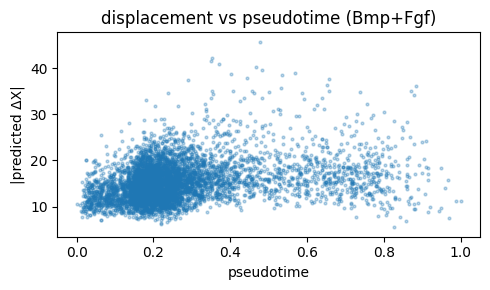

In [6]:
pt = adata.obs[pt_key].astype(float).values
mag = np.linalg.norm(dX_pert, axis=1)

plt.figure(figsize=(5, 3))
plt.scatter(pt, mag, s=4, alpha=0.3)
plt.xlabel("pseudotime"); plt.ylabel("|predicted ΔX|")
plt.title(f"displacement vs pseudotime ({pert})")
plt.tight_layout(); plt.show()

## 5. Plot the field on the embedding

Color cells by |ΔX| on a 2D embedding. Compute UMAP if the dataset has none.

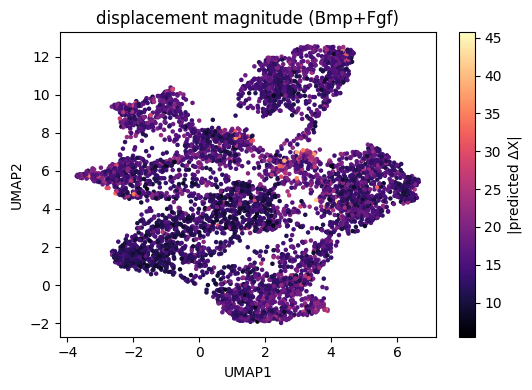

In [7]:
if "X_umap" not in adata.obsm:
    sc.pp.neighbors(adata, use_rep=setup["use_rep"])
    sc.tl.umap(adata)

emb = adata.obsm["X_umap"]
plt.figure(figsize=(5.5, 4))
sc_ = plt.scatter(emb[:, 0], emb[:, 1], c=np.linalg.norm(dX_pert, axis=1), s=5, cmap="magma")
plt.colorbar(sc_, label="|predicted ΔX|")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.title(f"displacement magnitude ({pert})")
plt.tight_layout(); plt.show()

### 5b. (Optional) arrows via PCA loadings

ΔX lives in gene space. If PCA loadings are stored in `adata.varm["PCs"]`, project ΔX into PC space and
draw arrows on the PCA scatter — an exact linear projection of the field. (UMAP arrows would need a
velocity-style transition projection; PCA is the simple, faithful version.)

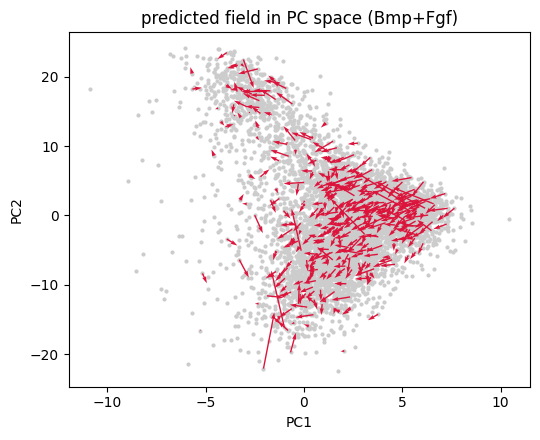

In [8]:
if "PCs" in adata.varm and "X_pca" in adata.obsm:
    PCs = np.nan_to_num(np.asarray(adata.varm["PCs"])[:, :2])   # (genes, 2); zero any NaN loadings
    dPC = dX_pert @ PCs                               # displacement in PC space
    xy = np.asarray(adata.obsm["X_pca"])[:, :2]
    step = max(1, adata.n_obs // 400)                 # thin the arrows
    s = slice(None, None, step)
    plt.figure(figsize=(5.5, 4.5))
    plt.scatter(xy[:, 0], xy[:, 1], s=4, c="0.8")
    plt.quiver(xy[s, 0], xy[s, 1], dPC[s, 0], dPC[s, 1],
               angles="xy", scale_units="xy", width=0.003, color="crimson")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"predicted field in PC space ({pert})")
    plt.tight_layout(); plt.show()
else:
    print("no PCA loadings in adata.varm['PCs'] — skip arrows")

## 6. Follow a trajectory by integrating the field

Because the net predicts a displacement, you can treat it as a vector field and Euler-integrate forward
from early cells: repeatedly add the predicted ΔX and advance the time index. The helper steps a few
seed cells (lowest pseudotime) forward.

In [9]:
import torch

def integrate_tracks(model, adata, condition, seeds, n_steps=25, step=1.0):
    # Euler-integrate the predicted dX field from seed cells.
    # Returns an array (n_seeds, n_steps+1, n_genes).
    s = model.setup
    tok = adata.uns["gendiff_token_dict"]
    cid = 0 if condition is None else tok[condition]
    mux = s["max_multiplexing"]
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    model._learner.to(dev).eval()

    import scipy.sparse as sp
    Xall = adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X)
    X = torch.tensor(Xall[seeds], dtype=torch.float32, device=dev)
    t = torch.tensor(adata.obs["discrete_time"].values[seeds].astype("int64"), device=dev)

    traj = [X.cpu().numpy().copy()]
    with torch.no_grad():
        for _ in range(n_steps):
            c = torch.full((X.shape[0], mux), cid, dtype=torch.long, device=dev)
            dX = model.module(X, c, None, t)
            X = X + step * dX
            t = torch.clamp(t + 1, max=model.timesteps - 1)
            traj.append(X.cpu().numpy().copy())
    return np.stack(traj, axis=1)

seeds = np.argsort(adata.obs[pt_key].astype(float).values)[:8]   # 8 earliest cells
tracks = integrate_tracks(model, adata, condition=pert, seeds=seeds, n_steps=25)
print("tracks shape (seeds, steps, genes):", tracks.shape)

tracks shape (seeds, steps, genes): (8, 26, 2000)


Two robust views of the integrated tracks: the per-step field magnitude (should decay as cells settle),
and the trajectories of the genes that move most under this condition.

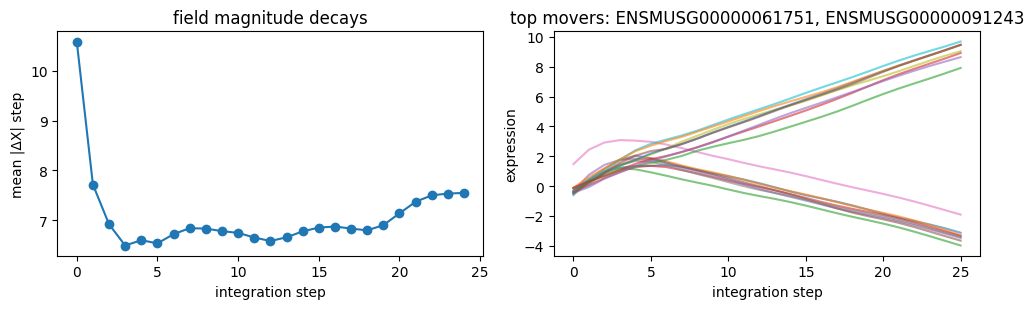

In [10]:
step_mag = np.linalg.norm(np.diff(tracks, axis=1), axis=2).mean(0)   # mean |step| per step
movers = np.argsort(np.abs(dX_pert.mean(0)))[::-1][:2]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(step_mag, marker="o")
ax[0].set_xlabel("integration step"); ax[0].set_ylabel("mean |ΔX| step"); ax[0].set_title("field magnitude decays")
for gi in movers:
    ax[1].plot(tracks[:, :, gi].T, alpha=0.6)
ax[1].set_xlabel("integration step"); ax[1].set_ylabel("expression")
ax[1].set_title(f"top movers: {', '.join(genes[movers])}")
plt.tight_layout(); plt.show()

## 7. (Optional) Compare predicted direction to RNA velocity

If the dataset carries a real RNA-velocity field (`adata.layers["velocity"]`, e.g. the `tfatlas_velo`
dataset — BarRNA-seq has none), the per-cell cosine between predicted ΔX and velocity is an external
direction check. The velocity layer must share the gene order of `adata.X`.

In [11]:
if "velocity" in adata.layers:
    import scipy.sparse as sp
    V = adata.layers["velocity"]
    V = V.toarray() if sp.issparse(V) else np.asarray(V)
    V = np.nan_to_num(V)
    d = model.predict_delta(adata, condition="ctrl")
    num = (d * V).sum(1)
    den = np.linalg.norm(d, axis=1) * np.linalg.norm(V, axis=1) + 1e-9
    cos = num / den
    print("median cosine(predicted ΔX, RNA velocity):", round(float(np.median(cos)), 3))
    plt.figure(figsize=(5, 3))
    plt.hist(cos[np.isfinite(cos)], bins=40)
    plt.xlabel("cosine(ΔX, velocity)"); plt.ylabel("cells"); plt.tight_layout(); plt.show()
else:
    print("no velocity layer on this dataset — see the tfatlas_velo dataset for this comparison")

no velocity layer on this dataset — see the tfatlas_velo dataset for this comparison


---
That covers the GenDiff downstream API: `predict_delta`, `predict_population`, and treating the learned
ΔX as an integrable field. See the top-level `README.md` for the full API reference.